# RNNs, seq2seq and attention — live companion (20 min)

This notebook is the **minimal live-code companion** for the final RNN slides. It is intentionally short: no dataset downloads and no long training loops.

**Reference notebooks from the book**

- [Chapter 13 — Processing Sequences Using RNNs and CNNs](https://colab.research.google.com/github/serivan/DeepLearning/blob/master/PyTorch/13_processing_sequences_using_rnns_and_cnns.ipynb)
- [Chapter 14 — NLP with RNNs and Attention](https://colab.research.google.com/github/serivan/DeepLearning/blob/master/PyTorch/14_nlp_with_rnns_and_attention.ipynb)


## 0. Setup — run once

Only PyTorch and Matplotlib are needed. The code is CPU-friendly.


In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)

print("PyTorch:", torch.__version__)
print("Device: CPU is sufficient for this companion")

PyTorch: 2.11.0+cpu
Device: CPU is sufficient for this companion


## 1. Vanilla RNN: the two returned objects are not the same thing
**Slides 9–15 — RNN cell, tensor convention, PyTorch semantics, unrolling**

Points to make while the cell runs:

- with `batch_first=True`, sequence tensors use **(batch, time, features)**;
- `output` contains the final-layer representation at **every timestep**;
- `h_n` contains **final-state metadata** for each layer/direction;
- in the simple one-layer, one-direction case, `output[:, -1]` and `h_n[0]` coincide.


In [2]:
N, T, D_x, D_h = 2, 5, 3, 4
x = torch.randn(N, T, D_x)

rnn = nn.RNN(
    input_size=D_x,
    hidden_size=D_h,
    batch_first=True
)

output, h_n = rnn(x)

print("x      ", tuple(x.shape), " = (N, T, D_x)")
print("output ", tuple(output.shape), " = (N, T, D_h)")
print("h_n    ", tuple(h_n.shape), " = (layers*directions, N, D_h)")
print("last output == final state?", torch.allclose(output[:, -1], h_n[0]))

# Same recurrent computation, two common task topologies:
token_level_features = output       # many-to-many aligned
sequence_summary = h_n[0]           # many-to-one summary
print("token-level:", tuple(token_level_features.shape))
print("summary:    ", tuple(sequence_summary.shape))

x       (2, 5, 3)  = (N, T, D_x)
output  (2, 5, 4)  = (N, T, D_h)
h_n     (1, 2, 4)  = (layers*directions, N, D_h)
last output == final state? True
token-level: (2, 5, 4)
summary:     (2, 4)


## 2. BPTT: repeated Jacobian factors can shrink or grow
**Slides 22–29 — BPTT, vanishing/exploding gradients, clipping, TBPTT**

The scalar recurrence below isolates the same repeated-product mechanism that appears in the RNN Jacobian product. Then we show the two practical PyTorch operations from the slides: gradient clipping and `detach()`.


In [3]:
def scalar_recurrence_grad(a_value, T):
    h0 = torch.tensor(1.0, requires_grad=True)
    h = h0
    a = torch.tensor(a_value)
    for _ in range(T):
        h = a * h
    h.backward()
    return h0.grad.item()

for a in (0.8, 1.2):
    for steps in (5, 20):
        g = scalar_recurrence_grad(a, steps)
        print(f"a={a:>3}, T={steps:>2}: dh_T/dh_0 = {g: .6f}  (expected {a**steps: .6f})")

# Gradient clipping: cap a deliberately enlarged gradient norm.
rnn.zero_grad()
out, _ = rnn(x)
loss = 1000 * out.pow(2).mean()
loss.backward()

def total_grad_norm(module):
    return torch.sqrt(sum((p.grad.detach()**2).sum() for p in module.parameters() if p.grad is not None))

before = total_grad_norm(rnn).item()
nn.utils.clip_grad_norm_(rnn.parameters(), max_norm=1.0)
after = total_grad_norm(rnn).item()
print(f"gradient norm: {before:.3f} -> {after:.3f}")

# TBPTT idea: keep the numerical state, cut the old graph.
_, h = rnn(x[:, :3])
h_carried = h.detach()
print("same shape/value carried forward:", tuple(h_carried.shape))
print("old gradient history attached?", h_carried.grad_fn is not None)

a=0.8, T= 5: dh_T/dh_0 =  0.327680  (expected  0.327680)
a=0.8, T=20: dh_T/dh_0 =  0.011529  (expected  0.011529)
a=1.2, T= 5: dh_T/dh_0 =  2.488320  (expected  2.488320)
a=1.2, T=20: dh_T/dh_0 =  38.337635  (expected  38.337600)
gradient norm: 590.286 -> 1.000
same shape/value carried forward: (1, 2, 4)
old gradient history attached? False


## 3. Perplexity is just exponentiated mean NLL
**Slide 30 — perplexity**

For next-token models, PyTorch cross-entropy already computes the mean negative log-likelihood. Therefore, with natural logarithms:

\[
\mathrm{PPL}=\exp(\mathrm{cross\ entropy}).
\]


In [4]:
logits = torch.tensor([
    [3.0, 0.2, -1.0],
    [0.1, 2.2,  0.3],
    [0.2, 0.1,  1.8],
])
target = torch.tensor([0, 1, 2])

ce = F.cross_entropy(logits, target)
ppl = ce.exp()
print(f"mean cross-entropy = {ce.item():.4f}")
print(f"perplexity         = {ppl.item():.4f}")

mean cross-entropy = 0.2141
perplexity         = 1.2387


## 4. LSTM and GRU: what PyTorch returns
**Slides 35–45 — gated recurrence, complete LSTM, complete GRU**

Keep the focus on the state structure:

- LSTM carries **two recurrent states**, `h` and `c`;
- GRU carries **one recurrent state**, `h`;
- `batch_first=True` changes sequence input/output layout, **not** the layout of `h_n` / `c_n`.


In [5]:
lstm = nn.LSTM(D_x, D_h, batch_first=True)
gru  = nn.GRU(D_x, D_h, batch_first=True)

lstm_output, (lstm_h, lstm_c) = lstm(x)
gru_output, gru_h = gru(x)

print("LSTM")
print(" output:", tuple(lstm_output.shape))
print(" h_n:   ", tuple(lstm_h.shape))
print(" c_n:   ", tuple(lstm_c.shape))

print("\nGRU")
print(" output:", tuple(gru_output.shape))
print(" h_n:   ", tuple(gru_h.shape))

print("\ntrainable parameters")
print(" LSTM:", sum(p.numel() for p in lstm.parameters()))
print(" GRU: ", sum(p.numel() for p in gru.parameters()))

LSTM
 output: (2, 5, 4)
 h_n:    (1, 2, 4)
 c_n:    (1, 2, 4)

GRU
 output: (2, 5, 4)
 h_n:    (1, 2, 4)

trainable parameters
 LSTM: 144
 GRU:  108


## 5. Layer depth and directionality change different axes
**Slides 46–50 — stacked and bidirectional recurrent networks**

Use one cell to make two slide claims concrete:

- output features concatenate the two directions: `2 * D_h`;
- final states keep layer and direction as metadata in the leading axis: `2 * L`.


In [6]:
L = 2
bi_lstm = nn.LSTM(
    D_x, D_h,
    num_layers=L,
    bidirectional=True,
    batch_first=True
)

bi_output, (bi_h, bi_c) = bi_lstm(x)
print("output:", tuple(bi_output.shape), "  # (N, T, 2*D_h)")
print("h_n:   ", tuple(bi_h.shape), "  # (2*L, N, D_h)")
print("c_n:   ", tuple(bi_c.shape), "  # (2*L, N, D_h)")

# Make the metadata axes explicit: (layer, direction, batch, hidden)
h_view = bi_h.view(L, 2, N, D_h)
print("reshaped h_n:", tuple(h_view.shape), " = (layer, direction, batch, hidden)")

output: (2, 5, 8)   # (N, T, 2*D_h)
h_n:    (4, 2, 4)   # (2*L, N, D_h)
c_n:    (4, 2, 4)   # (2*L, N, D_h)
reshaped h_n: (2, 2, 2, 4)  = (layer, direction, batch, hidden)


## 6. Seq2seq training: teacher forcing is target shifting
**Slides 51–55 — encoder/decoder, conditional LM, teacher forcing, decoding**

During training the decoder sees the **true previous target**. A compact way to see it is to shift the target sequence by one position and prepend `<BOS>`.

Beam search is intentionally **not implemented here**: the slide is more useful than live search code in a 20-minute companion.


In [7]:
BOS = 0
target = torch.tensor([[4, 7, 2, 9, 1]])  # one target sequence

decoder_input = torch.cat([
    torch.full((target.size(0), 1), BOS),
    target[:, :-1]
], dim=1)

print("target tokens: ", target.tolist())
print("decoder input: ", decoder_input.tolist())
print("                  ^ BOS, then the true previous target")

target tokens:  [[4, 7, 2, 9, 1]]
decoder input:  [[0, 4, 7, 2, 9]]
                  ^ BOS, then the true previous target


## 7. Attention: score → softmax → weighted sum
**Slides 59–66 — recurrent encoder–decoder attention and soft alignment**

This toy example uses scaled dot-product scores only because the computation is compact. The slide-level interpretation is the same for Bahdanau/Luong attention:

1. compare a decoder query with source keys;
2. normalize scores over source positions;
3. take a weighted sum of source values.

Across decoder steps, the rows of the weight tensor form a **soft alignment matrix**.


scores:  (1, 4, 6)  = (N, T_target, T_source)
weights: (1, 4, 6)
context: (1, 4, 8)  = (N, T_target, D)
row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000])


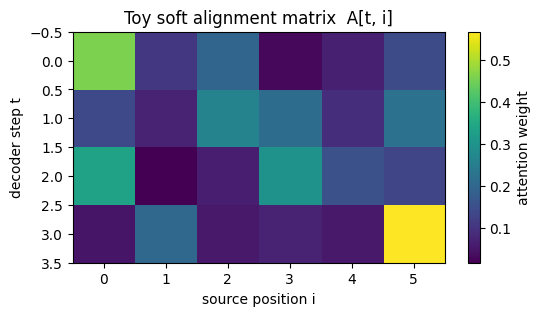

In [8]:
N, T_src, T_tgt, D = 1, 6, 4, 8
encoder_states = torch.randn(N, T_src, D)
decoder_queries = torch.randn(N, T_tgt, D)

# Here keys = values = encoder states, as in the simplest seq2seq view.
scores = decoder_queries @ encoder_states.transpose(-2, -1) / math.sqrt(D)
A = scores.softmax(dim=-1)
context = A @ encoder_states

print("scores: ", tuple(scores.shape), " = (N, T_target, T_source)")
print("weights:", tuple(A.shape))
print("context:", tuple(context.shape), " = (N, T_target, D)")
print("row sums:", A[0].sum(dim=-1))

plt.figure(figsize=(6, 3))
plt.imshow(A[0].detach(), aspect="auto")
plt.xlabel("source position i")
plt.ylabel("decoder step t")
plt.title("Toy soft alignment matrix  A[t, i]")
plt.colorbar(label="attention weight")
plt.show()

## 8. Q/K/V and self-attention: same retrieval pattern, same sequence
**Slides 65 and 69 — query/key/value abstraction and self-attention**

For self-attention, queries, keys and values are all projected from the **same input sequence**. The important tensor to point out is the `T × T` score/weight matrix: every query position scores every key position.


In [9]:
N, T, D_model, D_k = 1, 5, 8, 4
X = torch.randn(N, T, D_model)

W_Q = torch.randn(D_model, D_k)
W_K = torch.randn(D_model, D_k)
W_V = torch.randn(D_model, D_k)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

S = Q @ K.transpose(-2, -1) / math.sqrt(D_k)
A_self = S.softmax(dim=-1)
Y = A_self @ V

print("X:      ", tuple(X.shape))
print("Q,K,V:  ", tuple(Q.shape), tuple(K.shape), tuple(V.shape))
print("scores:  ", tuple(S.shape), "  # one T x T matrix per batch item")
print("weights: ", tuple(A_self.shape))
print("output Y:", tuple(Y.shape))
print("row sums:", A_self[0].sum(dim=-1))

X:       (1, 5, 8)
Q,K,V:   (1, 5, 4) (1, 5, 4) (1, 5, 4)
scores:   (1, 5, 5)   # one T x T matrix per batch item
weights:  (1, 5, 5)
output Y: (1, 5, 4)
row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


## What we deliberately do **not** run live

To keep the companion under 20 minutes, the following remain in the slides or in the full reference notebooks:

- long time-series training experiments;
- character-level language-model training;
- full encoder–decoder translation training;
- beam-search implementation details;
- full attention-based translation systems.

For these, use the two book notebooks linked at the top. The live companion is meant to make the **tensor semantics and computation graph** concrete while the corresponding slides are on screen.
